In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from uncertainties import ufloat, correlated_values
import uncertainties.unumpy as unp

3.257577973522481e-08 1.0
7.628851955128921e-08 1.0
2.1102425447477276e-07 0.9999999999999999
4.895251193513819e-07 0.9999999999999997
1.0051349706324212e-06 0.9999999999999997
1.7746358692549545e-06 1.0000000000000002
3.0643306319799484e-06 0.9999999999999997
5.264331685445152e-06 0.9999999999999997
9.074856711309178e-06 1.0
1.460709109335172e-05 1.0000000000000002
2.2910274019339607e-05 1.0000000000000002
3.507658760719944e-05 0.9999999999999997
5.246023431492345e-05 1.0000000000000002
7.669202598879085e-05 1.0000000000000002
0.00010969043861023886 1.0
0.0001537263095991916 0.9999999999999997
0.00021148741393203985 0.9999999999999999
0.0002860584578077999 0.9999999999999999
0.0003806505642929424 0.9999999999999999
0.0004980592330620963 1.0000000000000002
0.0006401978078796476 1.0000000000000002
0.000807830664449374 1.0000000000000002


C:\Users\jleng\AppData\Local\Temp\ipykernel_46744\2822962286.py:44: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 3, figsize=(18, 6))


0.001000547009171349 1.0
0.001216678093311095 1.0000000000000002
0.0014530226544156224 0.9999999999999999
0.001704419977328327 0.9999999999999996
0.001963262475134571 0.9999999999999996
0.0022191612494239215 1.0
0.0024590953403569346 0.9999999999999999
0.0026682085427579627 1.0000000000000002
0.002831383368142986 1.0


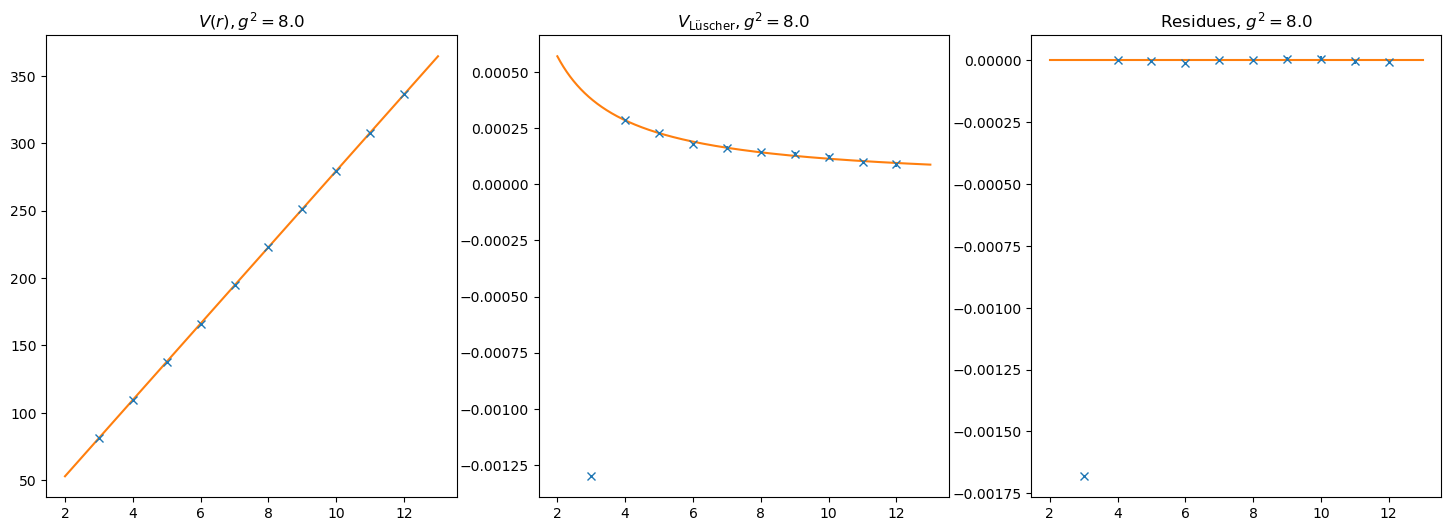

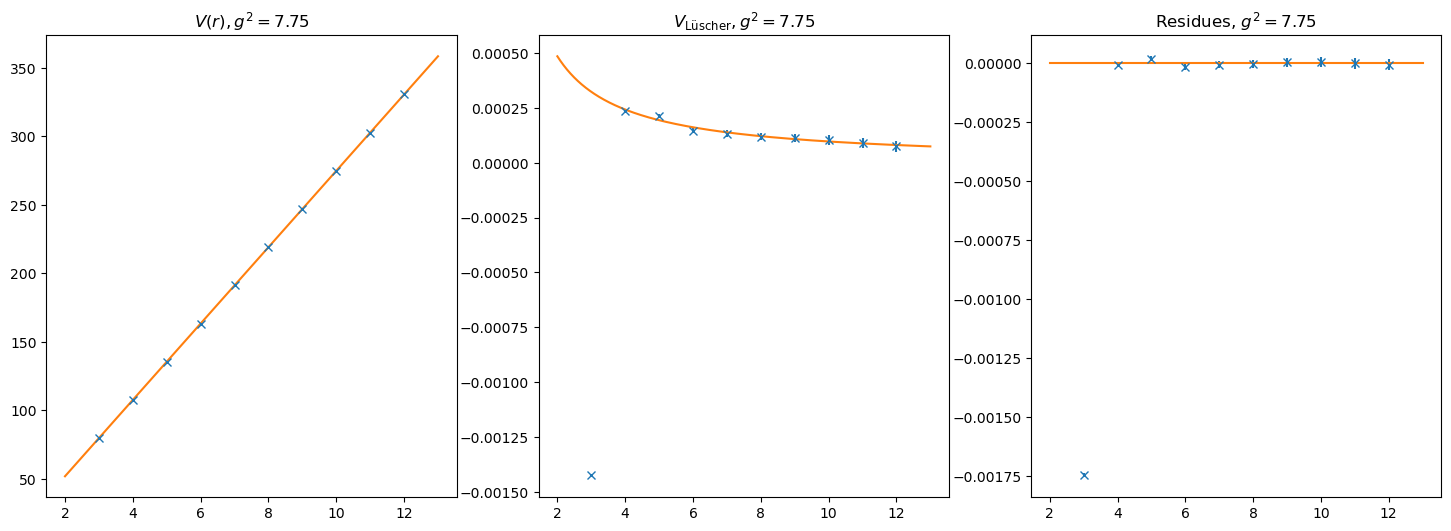

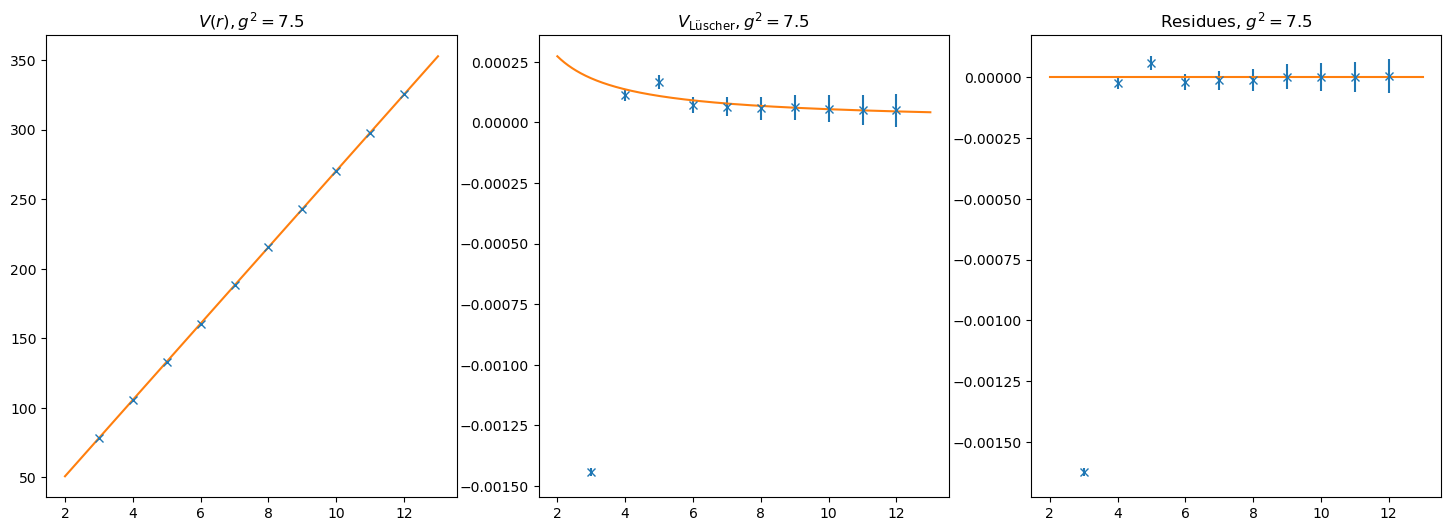

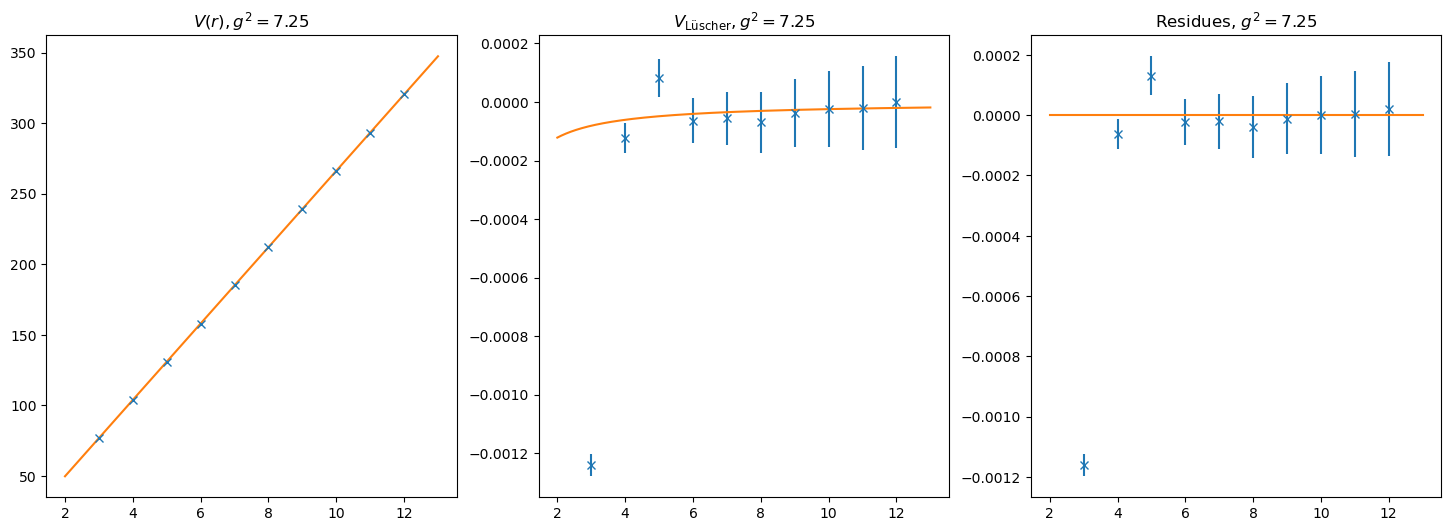

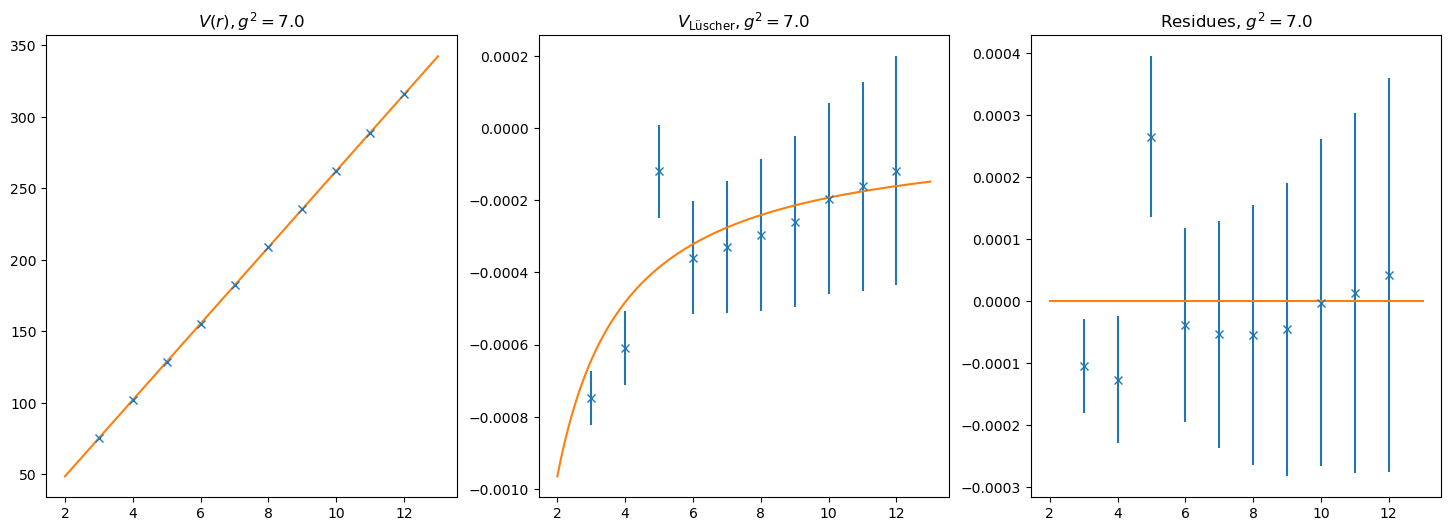

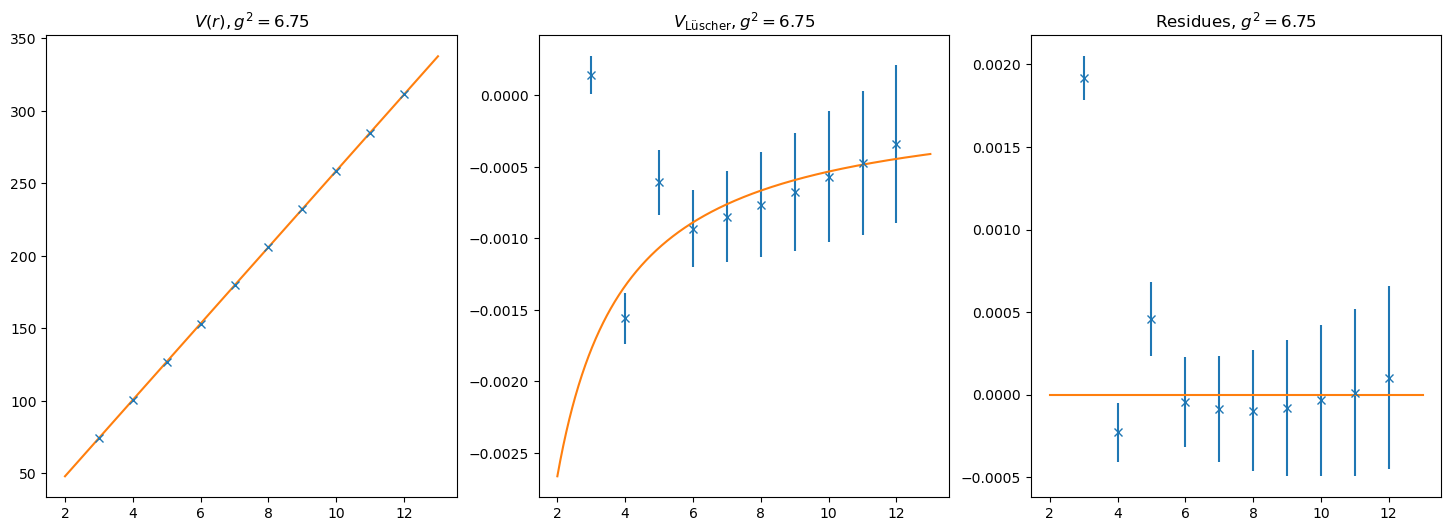

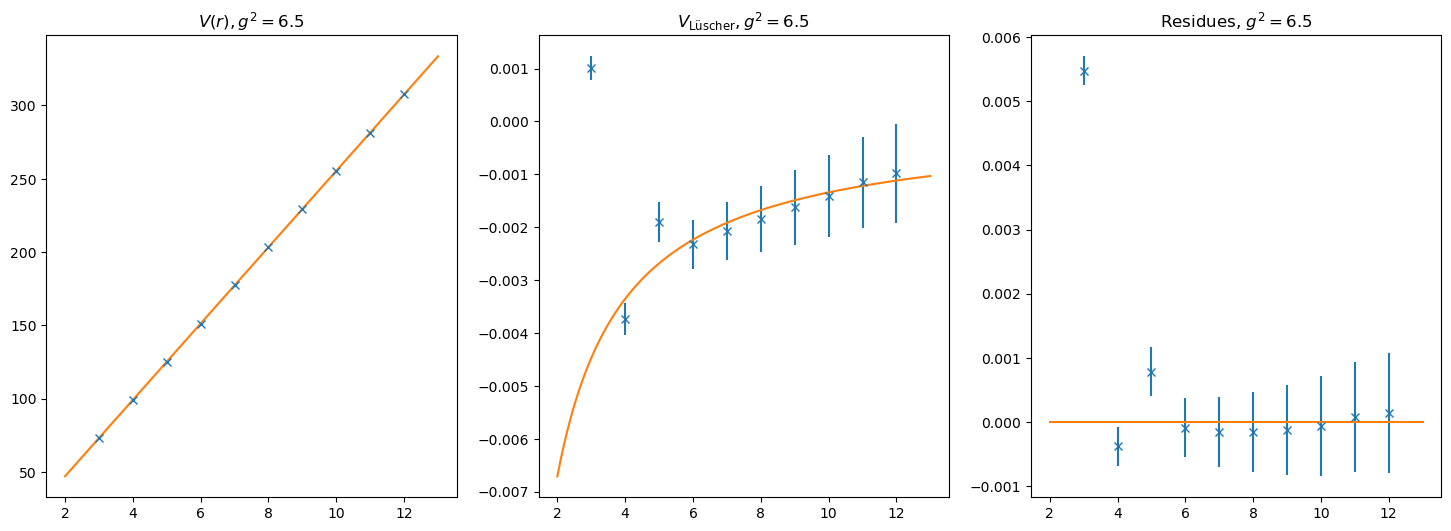

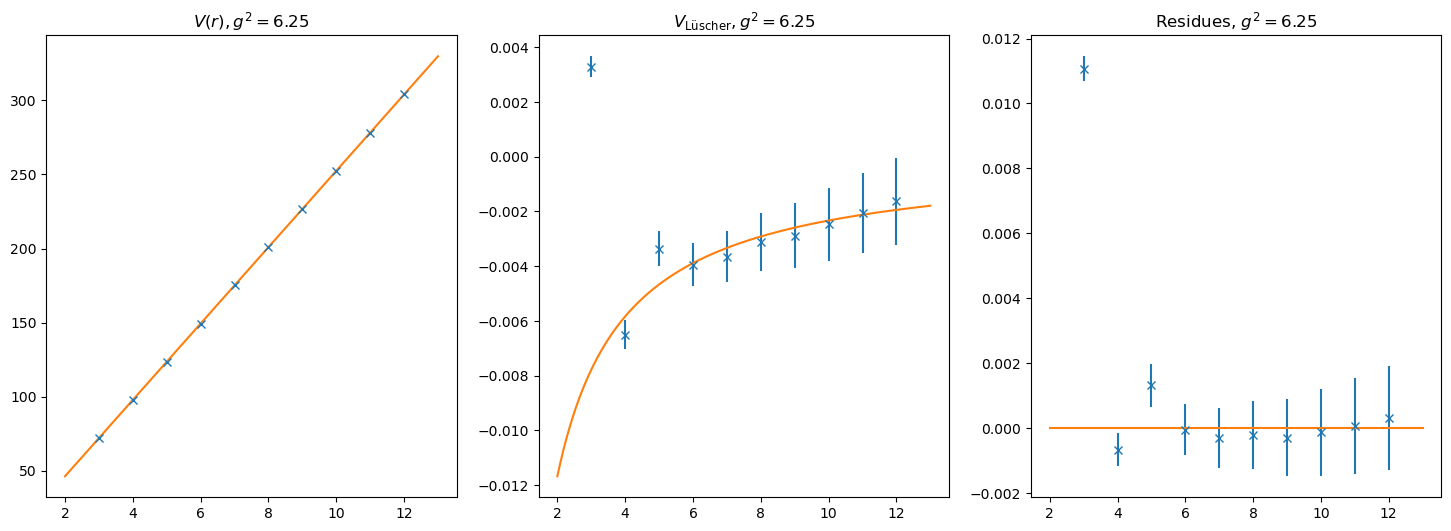

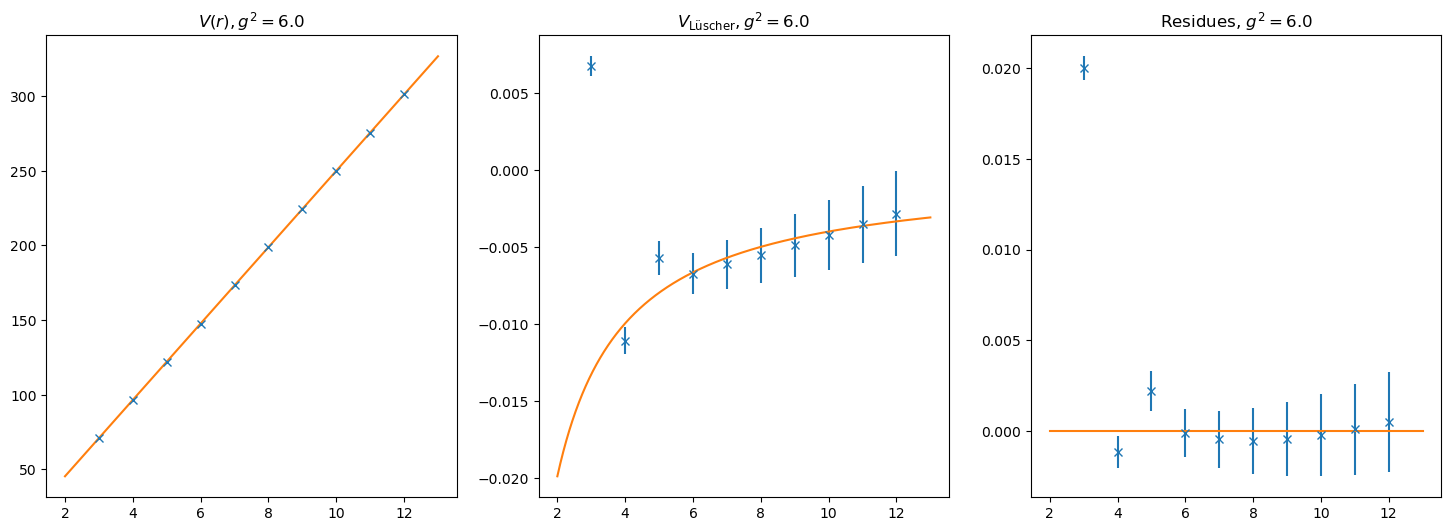

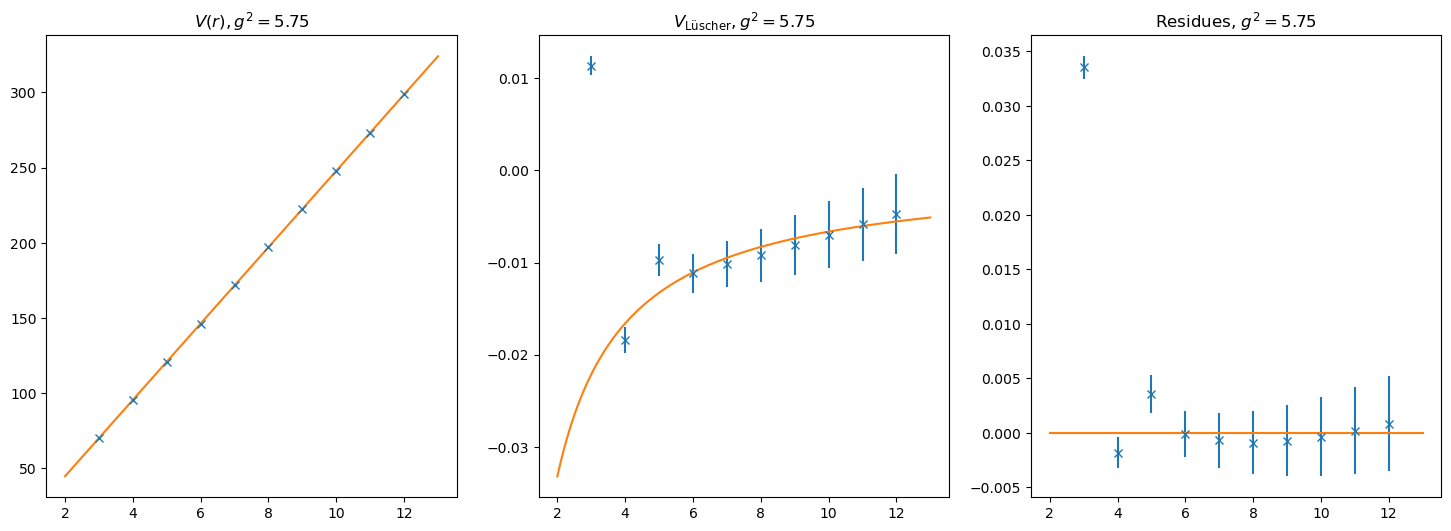

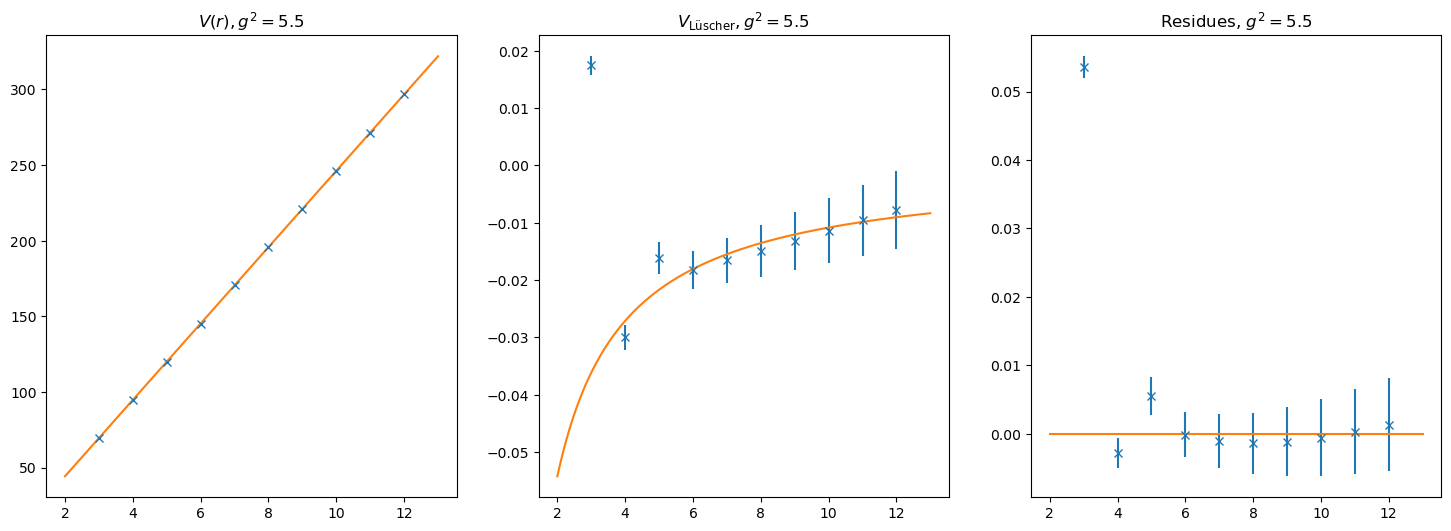

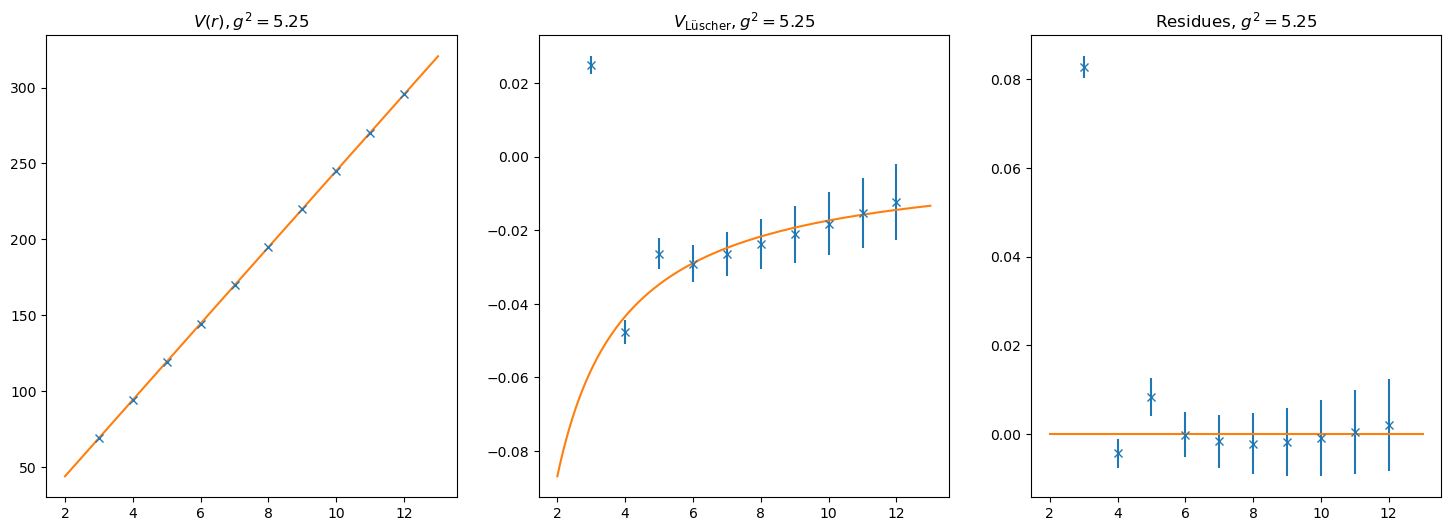

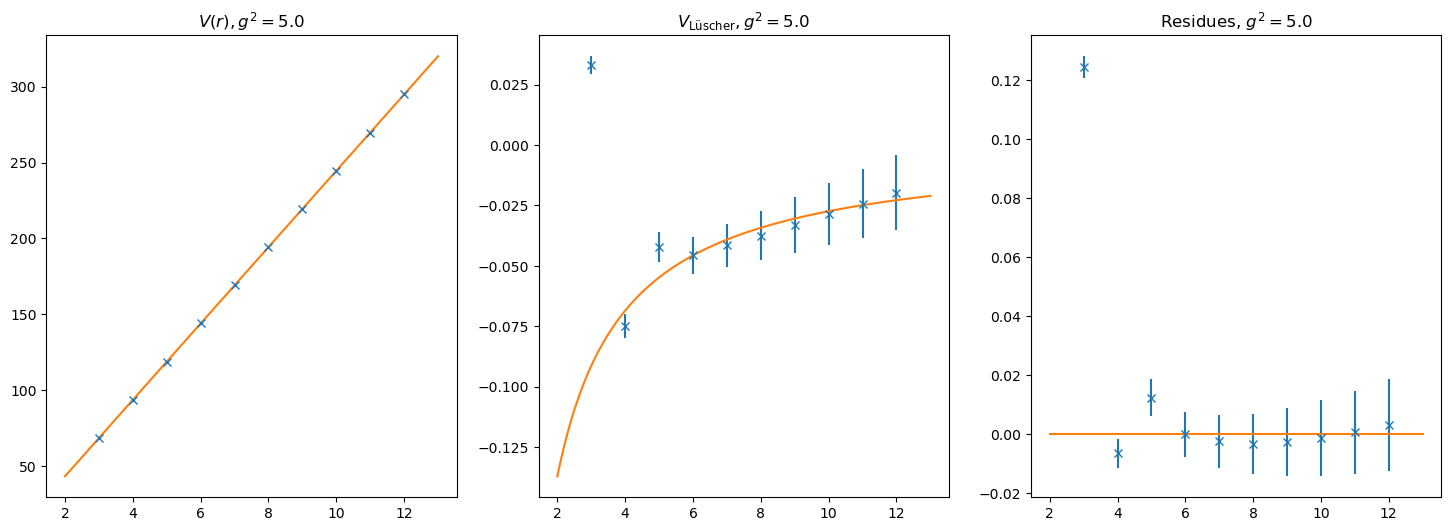

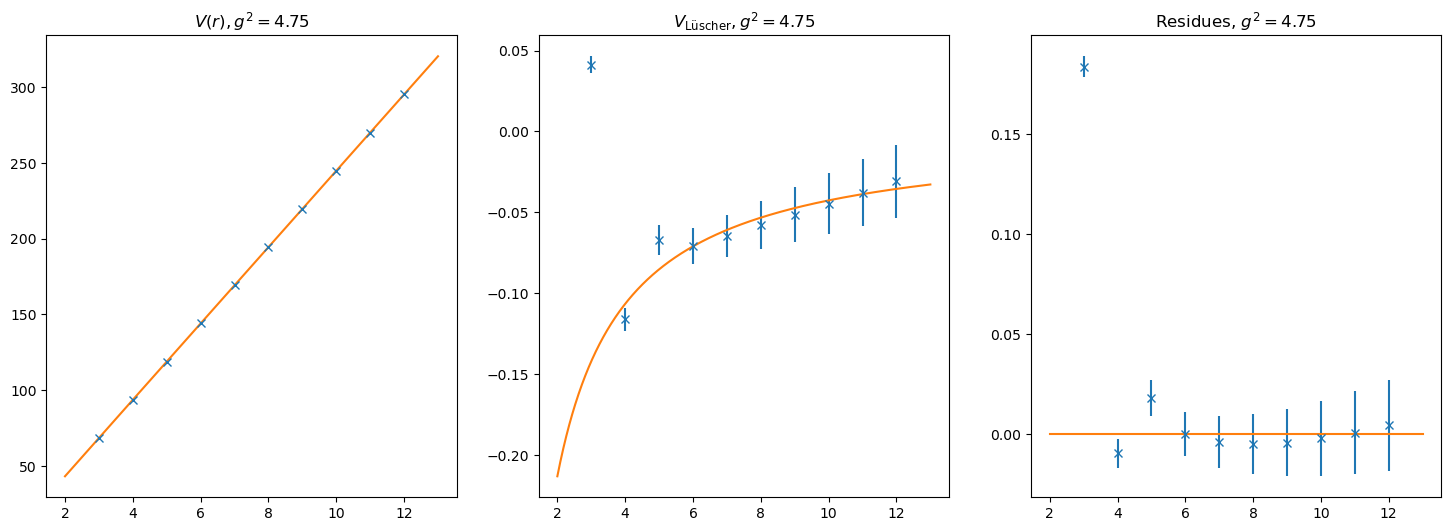

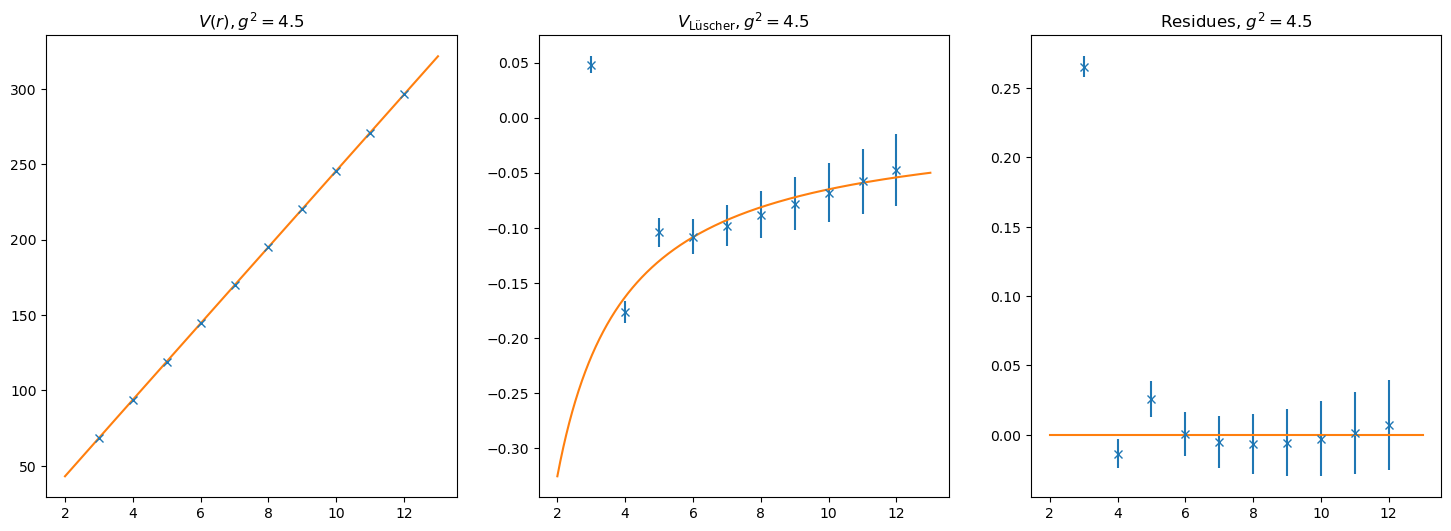

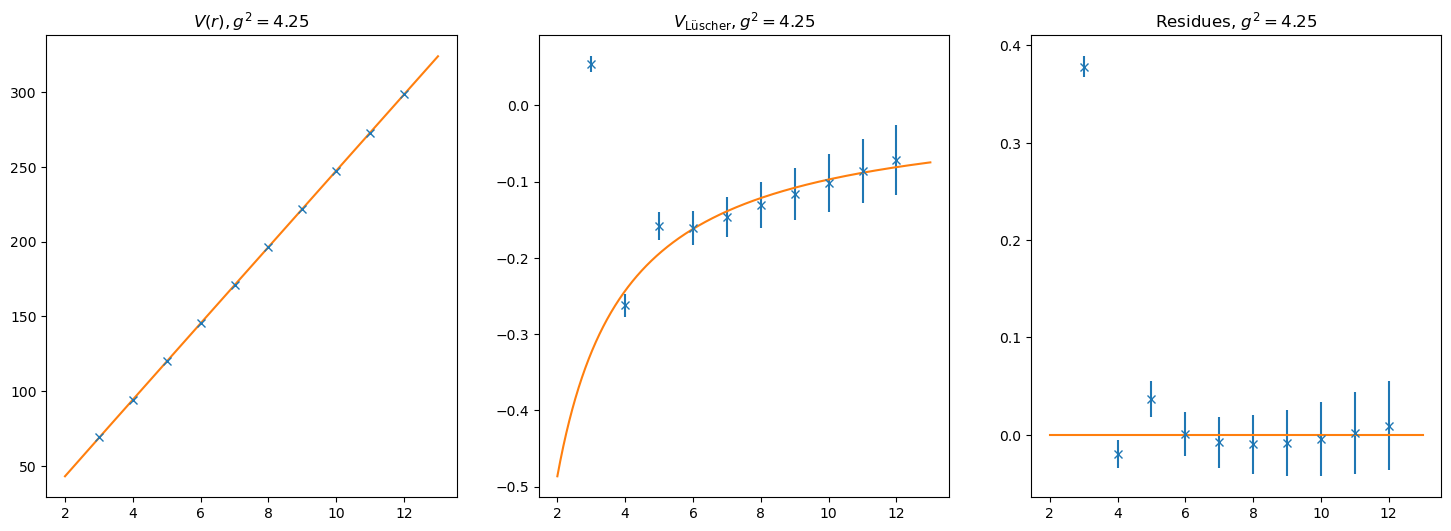

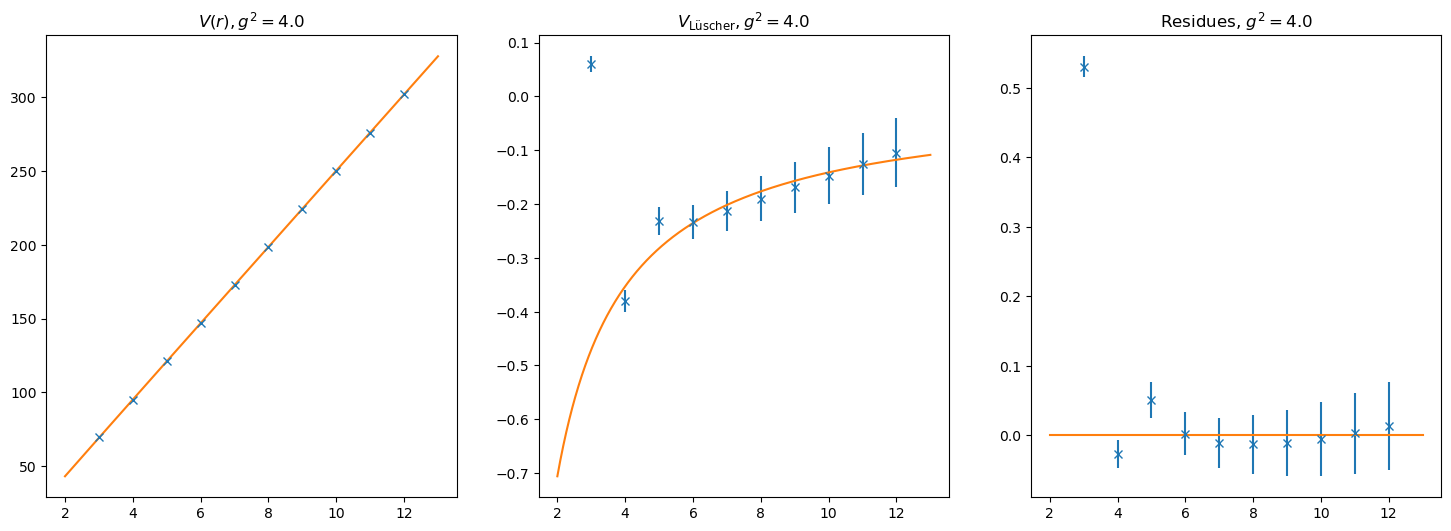

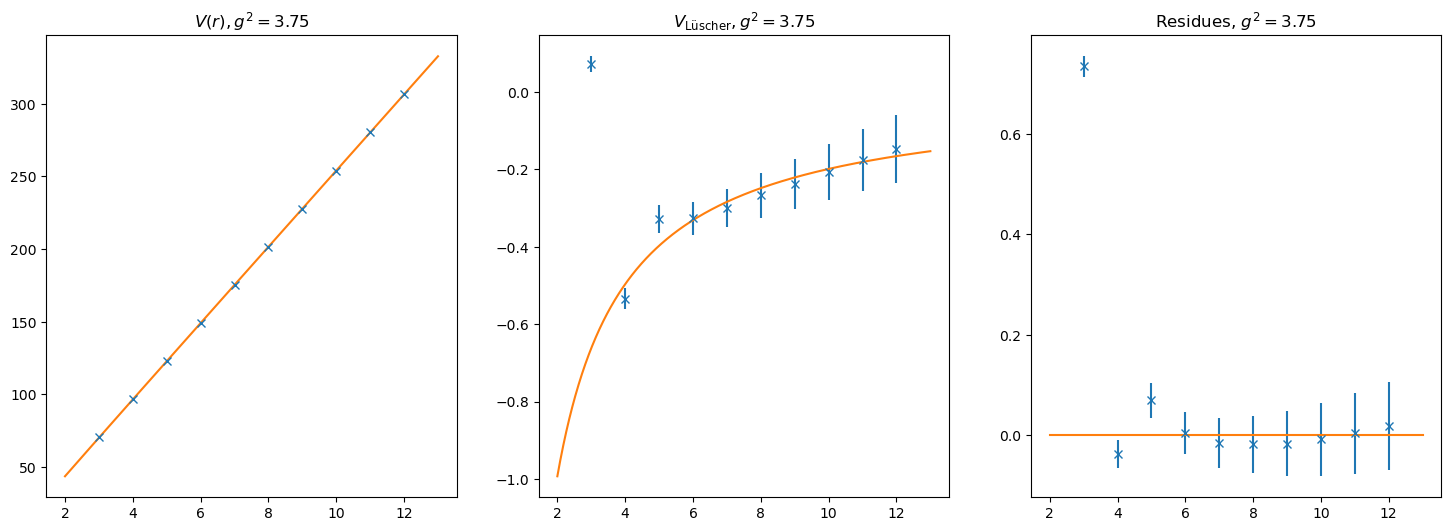

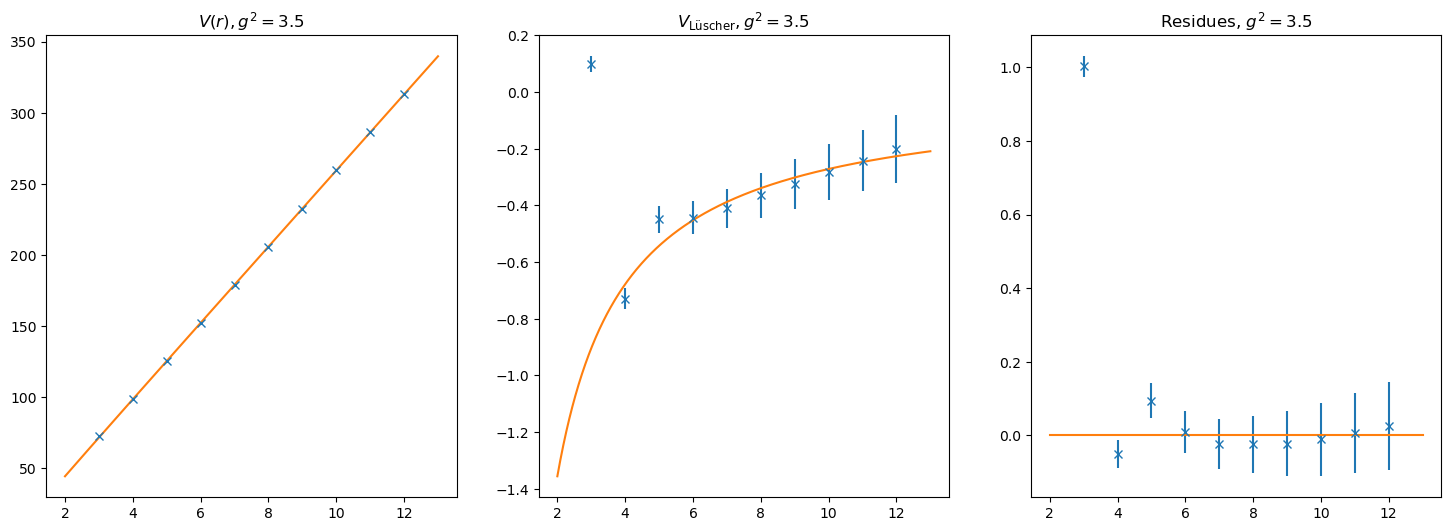

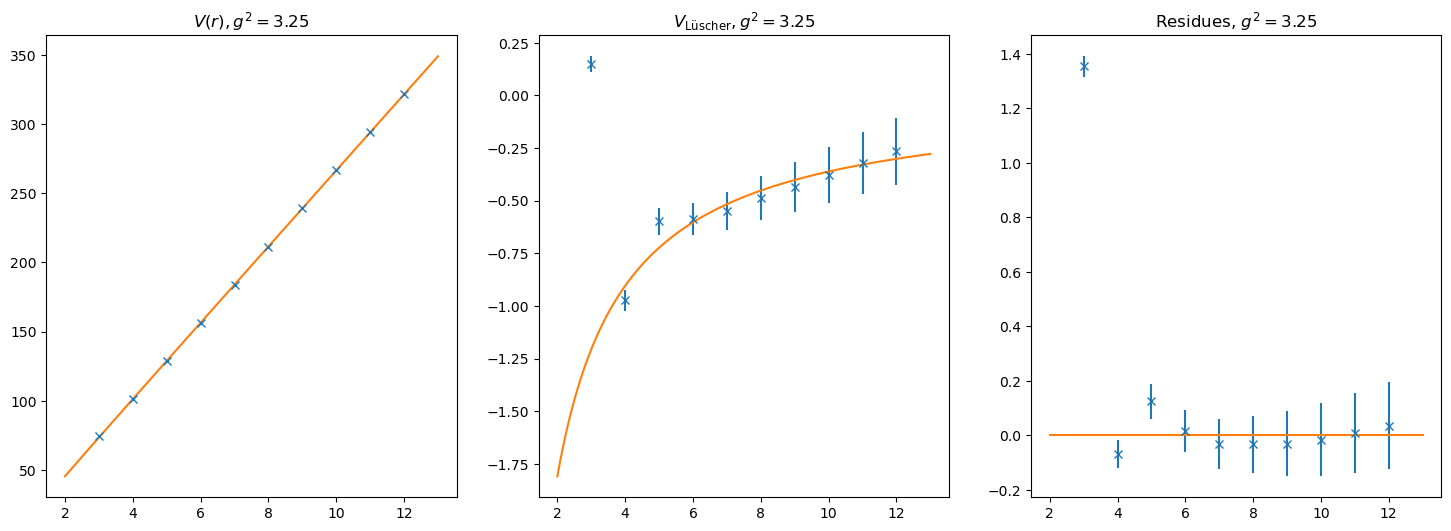

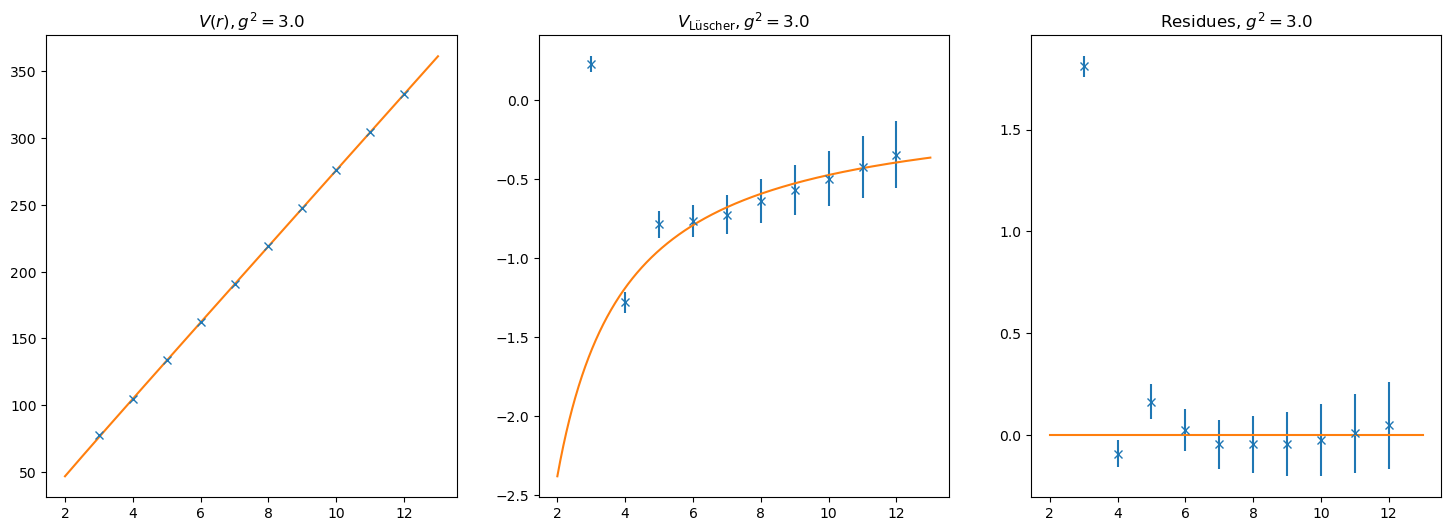

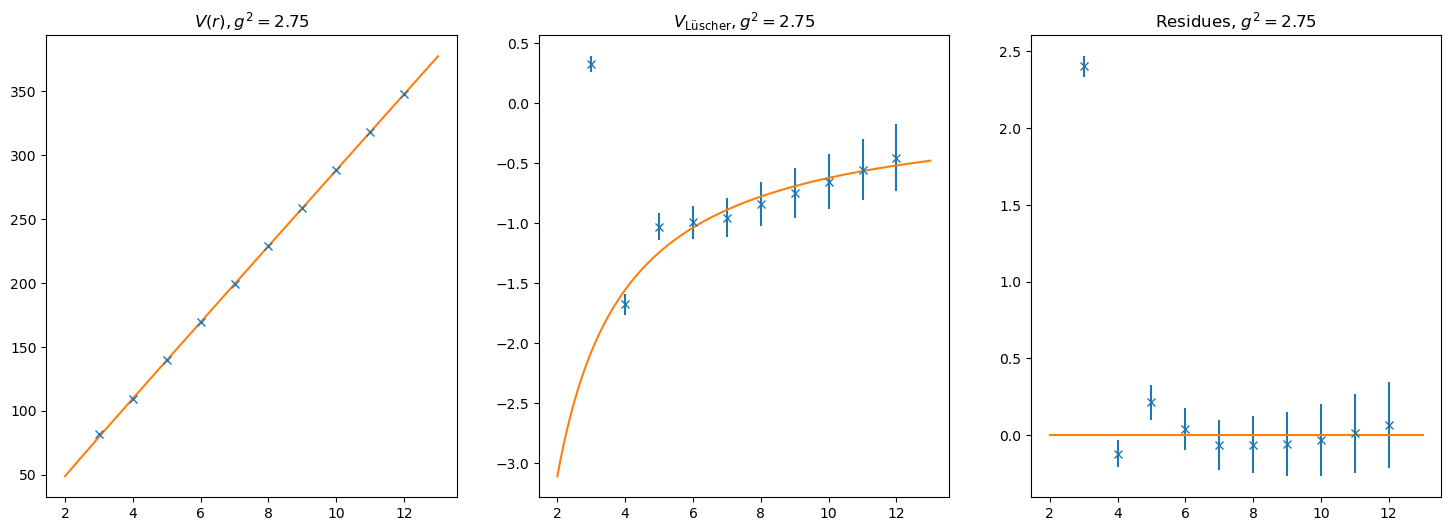

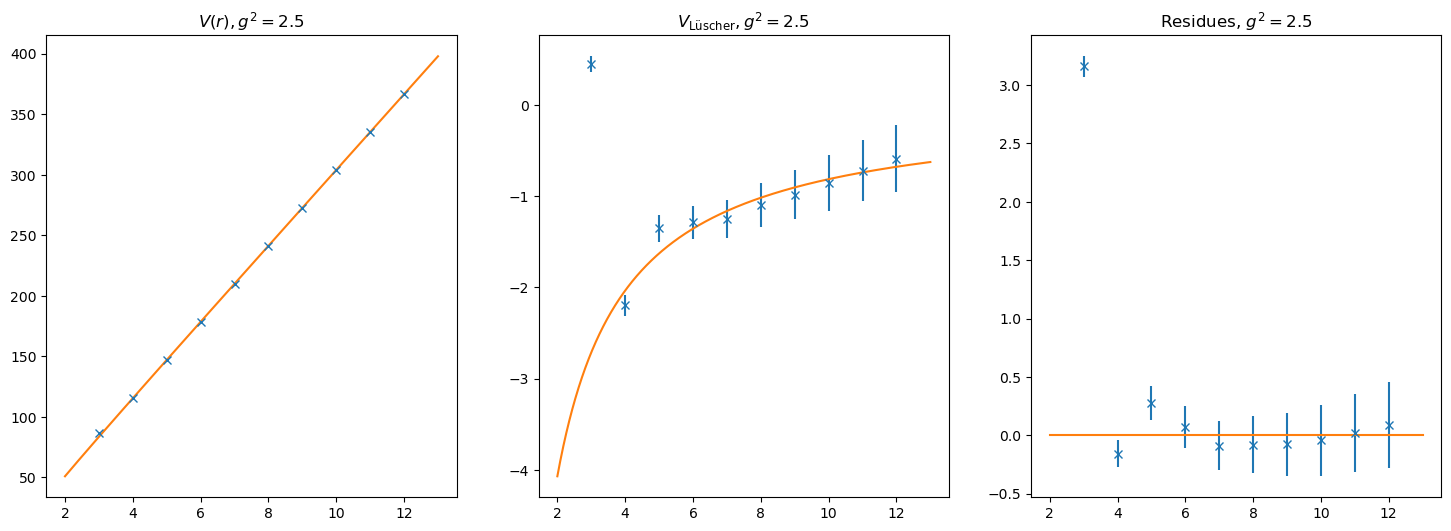

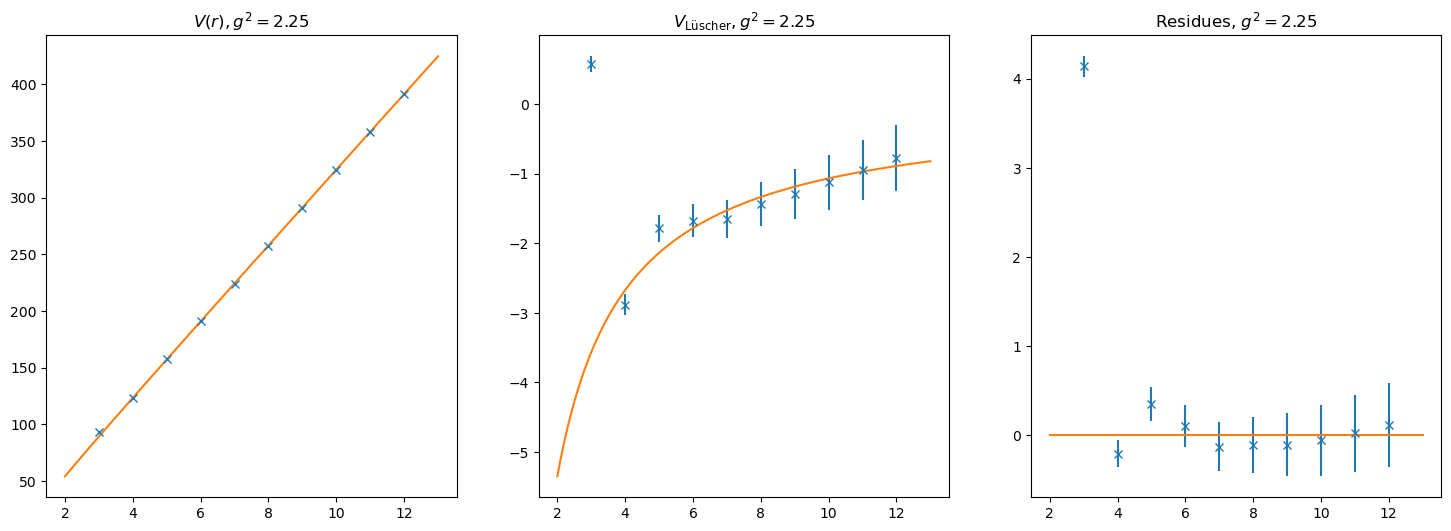

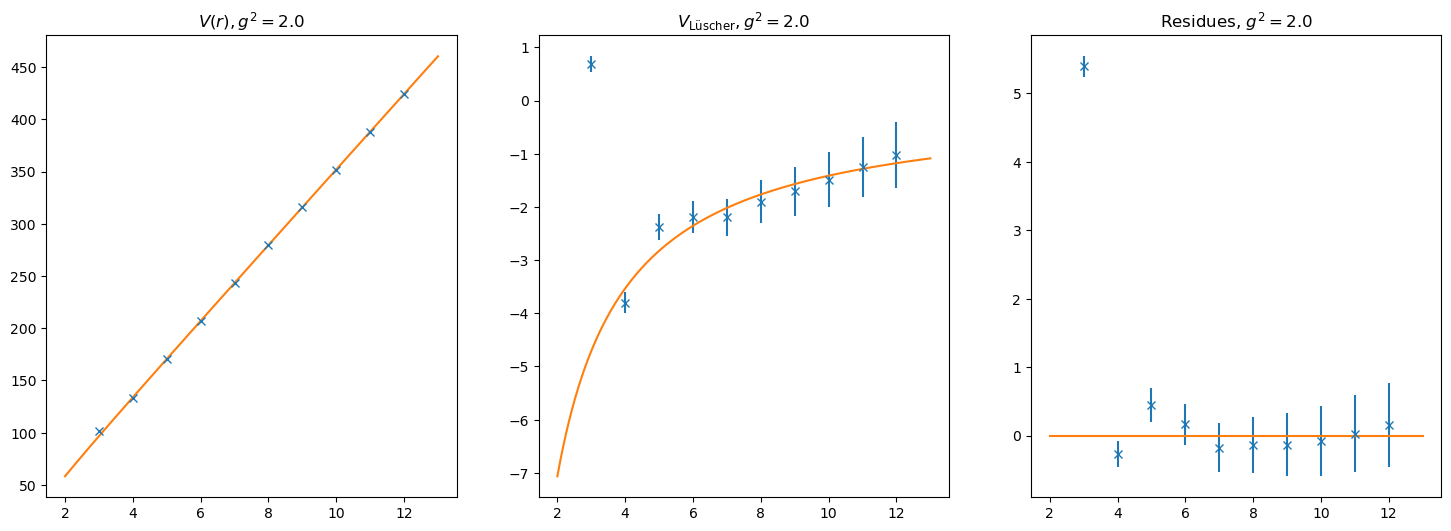

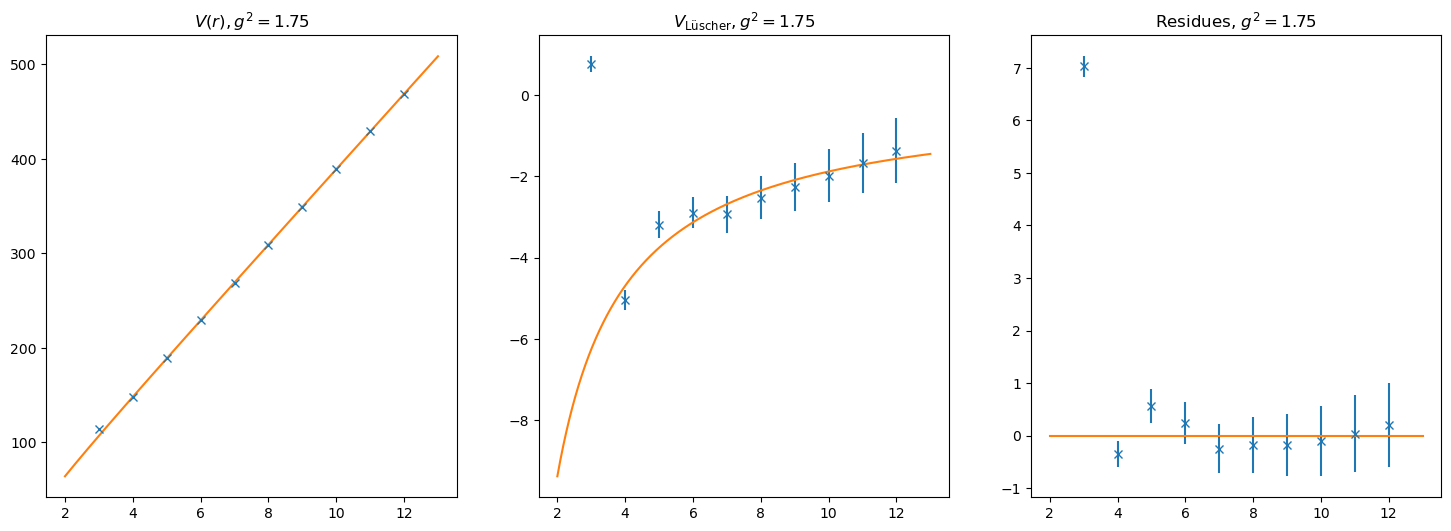

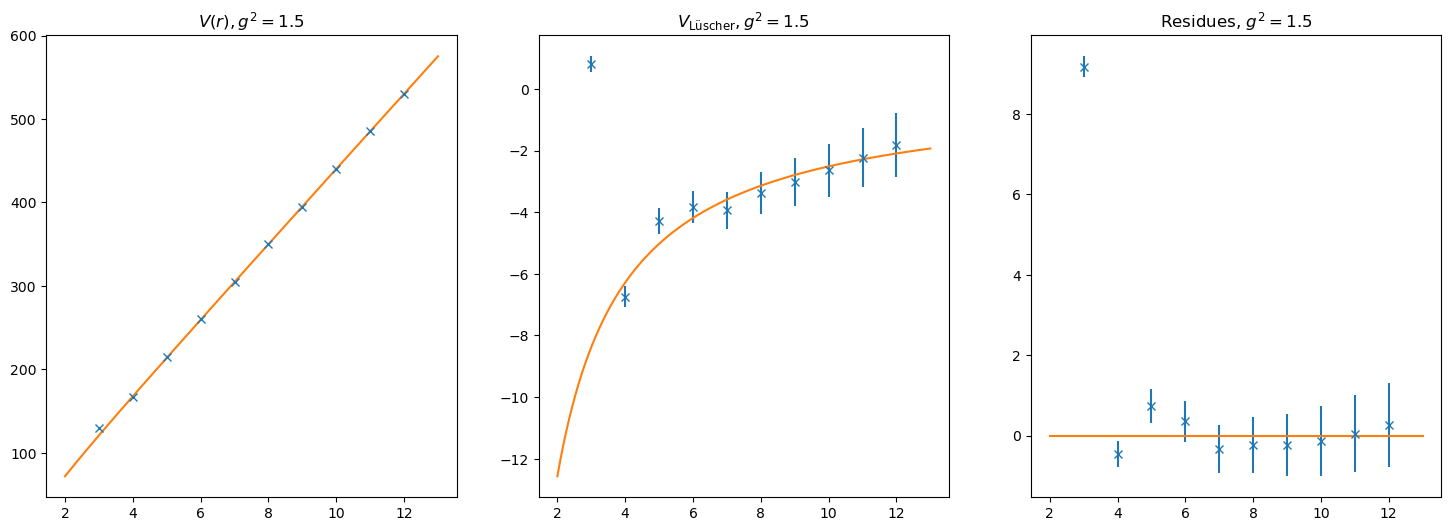

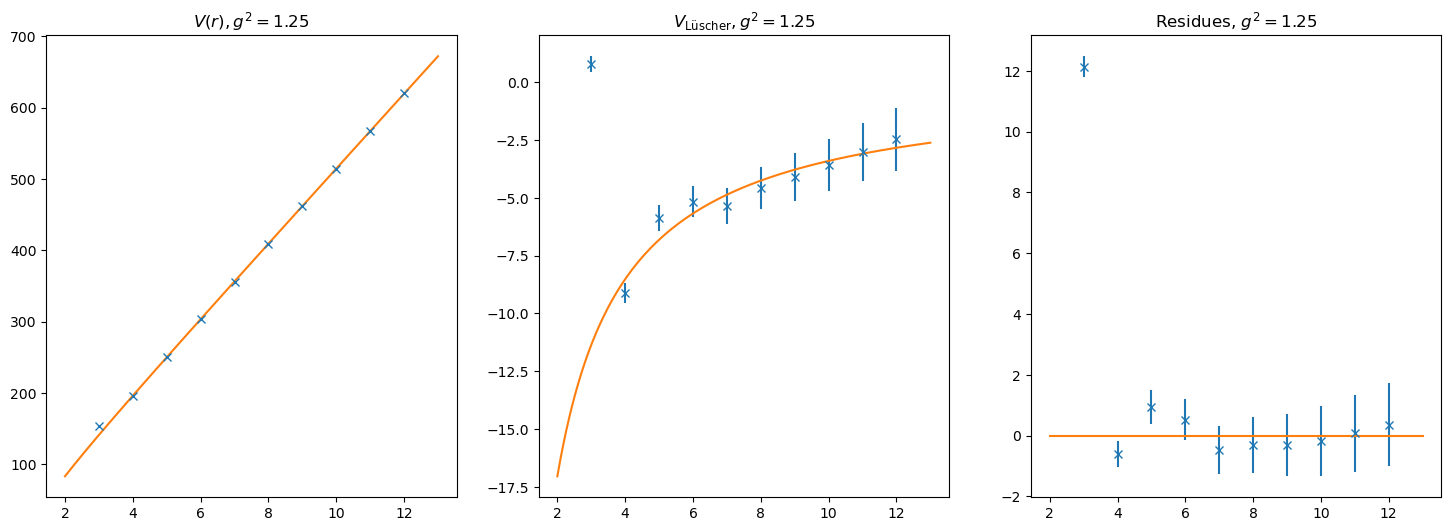

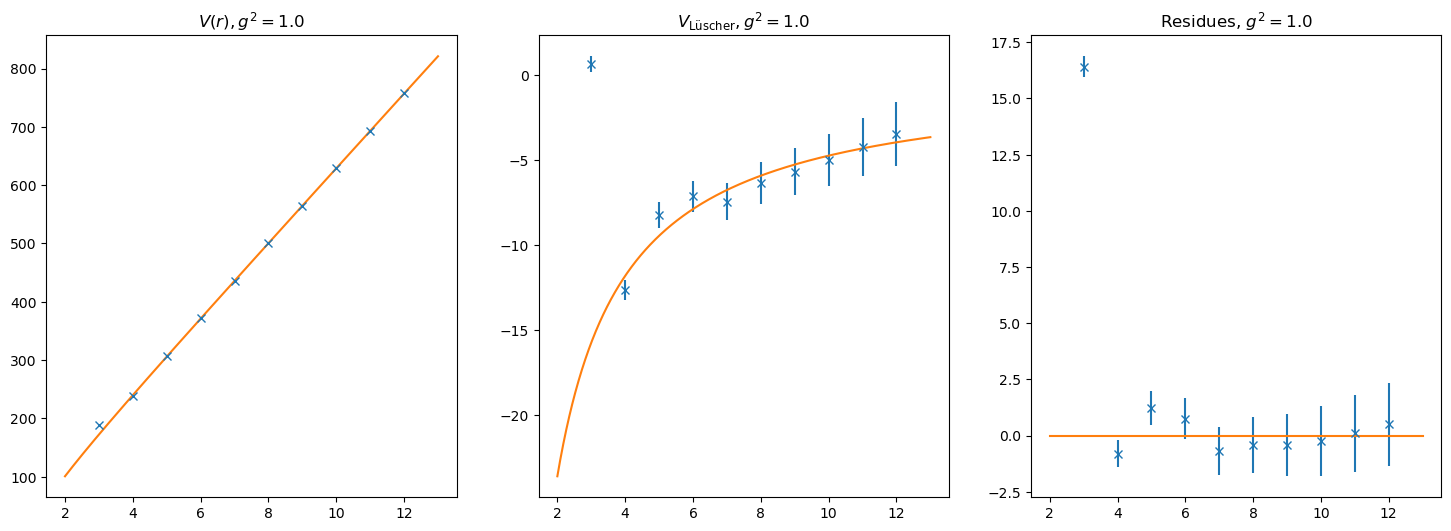

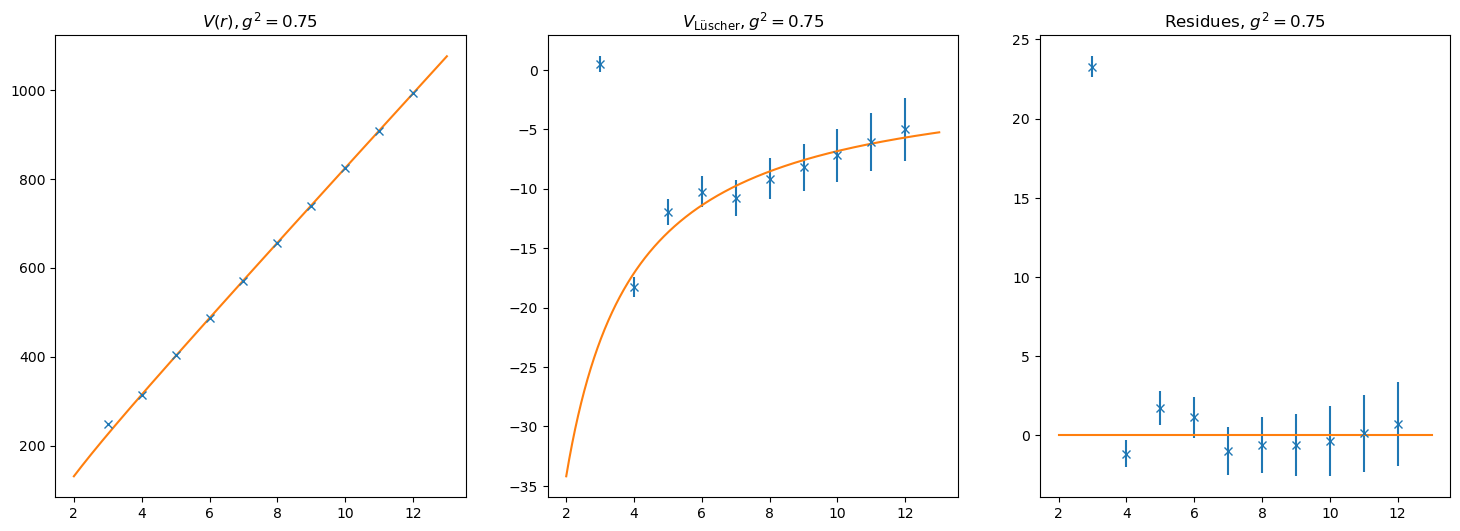

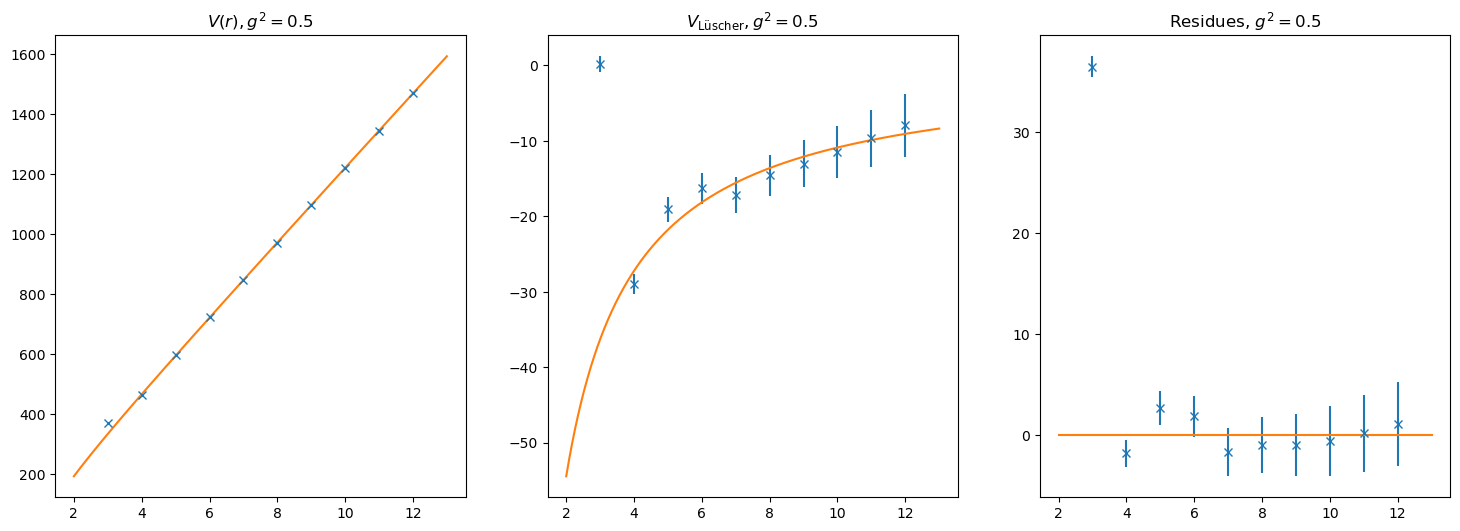

In [15]:
Nx = 4
Ny = np.arange(3, 13, 1)
Ny_fit_filter = Ny > 3
r = Ny

g2 = np.loadtxt("NX4/ground/AAA_g2_4x3.txt")

Estring = []
Eground = []

for y in Ny:
    Eground.append(np.loadtxt(f"NX4/ground/AAA_E_{Nx}x{y}.txt"))
    Estring.append(np.loadtxt(f"NX4/string/AAA_E_{Nx}x{y}.txt"))

Eground = np.array(Eground)
Estring = np.array(Estring)

V = Estring - Eground

def cornell(r, gamma, sigma, c):
    return gamma / r + sigma * r + c

def simplified(r, sigma, c):
    return sigma * r + c

gamma = []
sigma = []
c = []

for i, g in enumerate(g2):
    opt, cov = sp.optimize.curve_fit(cornell, Ny[Ny_fit_filter], V[Ny_fit_filter,i])
    # chi2 = np.sum(((V[:,i] - cornell(Ny, *opt)) / (V[:,i] * dVrel))**2) / dof = 1
    # => dVrel = np.sqrt(np.sum(((V[:,i] - cornell(Ny, *opt)) / V[:,i])**2) / dof)
    dof = len(Ny[1:]) - len(opt)
    dVrel = (np.sum(((V[Ny_fit_filter,i] - cornell(Ny[Ny_fit_filter], *opt)) / V[Ny_fit_filter,i])**2) / dof)**0.5
    chi2 = np.sum(((V[Ny_fit_filter,i] - cornell(Ny[Ny_fit_filter], *opt)) / (V[Ny_fit_filter,i] * dVrel))**2) / dof
    print(dVrel, chi2)

    Ny_fit = np.linspace(2, 13, 1000)
    gamma.append(ufloat(opt[0], cov[0][0]**0.5))
    sigma.append(ufloat(opt[1], cov[1][1]**0.5))
    c.append(ufloat(opt[2], cov[2][2]**0.5))

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].set_title(fr"$V(r), g^2={round(g, 2)}$")
    ax[0].errorbar(Ny, V[:,i], dVrel * V[:,i], fmt='x')
    ax[0].plot(Ny_fit, cornell(Ny_fit, *opt))

    ax[1].set_title(r"$V_\mathrm{L\"uscher}, g^2={" + str(round(g, 2)) + "}$")
    ax[1].errorbar(Ny, V[:,i] - simplified(Ny, opt[1], opt[2]), dVrel * np.abs(V[:,i]), fmt='x')
    ax[1].plot(Ny_fit, cornell(Ny_fit, *opt) - simplified(Ny_fit, opt[1], opt[2]))

    ax[2].set_title(r"Residues, $g^2={" + str(round(g, 2)) + "}$")
    ax[2].errorbar(Ny, V[:,i] - cornell(Ny, *opt), dVrel * np.abs(V[:,i]), fmt='x')
    ax[2].plot(Ny_fit, [0] * len(Ny_fit))
    fig.savefig(f"NX4/images/V_g2_{round(g, 2)}.png")

gamma = np.array(gamma)
sigma = np.array(sigma)
c = np.array(c)

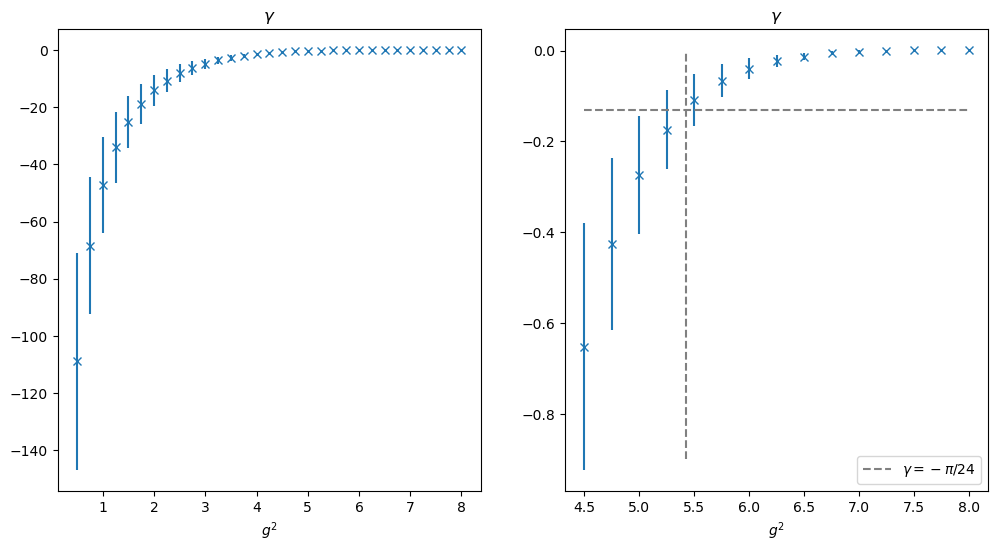

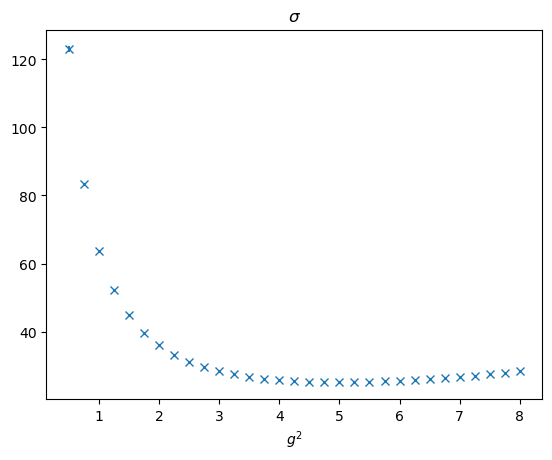

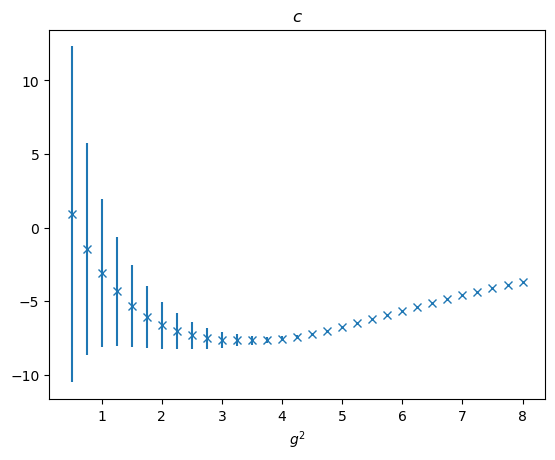

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title(r"$\gamma$")
ax[0].set_xlabel(r"$g^2$")
#ax[0].yscale("log")
ax[0].errorbar(g2, unp.nominal_values(gamma), unp.std_devs(gamma), fmt='x')

ax[1].set_title(r"$\gamma$")
ax[1].set_xlabel(r"$g^2$")
#ax[1].yscale("log")
ax[1].errorbar(g2[:-16], unp.nominal_values(gamma[:-16]), unp.std_devs(gamma[:-16]), fmt='x')
ax[1].plot([5.425]*2, [-0.9, 0], ls='--', color='gray')
ax[1].plot([4.5, 8], [-np.pi/24]*2, ls='--', color='gray', label=r"$\gamma=-\pi/24$")
ax[1].legend()
fig.savefig("NX4/images/gamma.png")

#def gamma_theo(x, a, b):
#    return a * x**b

#opt, cov = sp.optimize.curve_fit(gamma_theo, g2, unp.nominal_values(gamma), sigma=unp.std_devs(gamma), absolute_sigma=True, p0=(0, -1))
#print(unp.uarray(opt, np.diag(cov)**0.5))

#gamma_fit = np.linspace(0.25, 9, 1000)
#plt.plot(gamma_fit, gamma_theo(gamma_fit, *opt))

plt.figure()
plt.title(r"$\sigma$")
plt.xlabel(r"$g^2$")
plt.errorbar(g2, unp.nominal_values(sigma), unp.std_devs(sigma), fmt='x')
plt.savefig("NX4/images/sigma.png")

plt.figure()
plt.title(r"$c$")
plt.xlabel(r"$g^2$")
plt.errorbar(g2, unp.nominal_values(c), unp.std_devs(c), fmt='x')
plt.savefig("NX4/images/c.png")

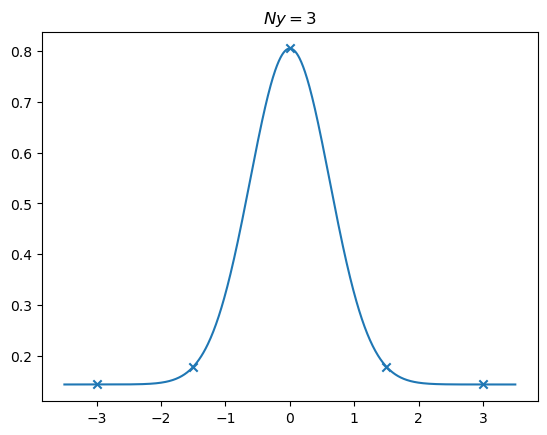

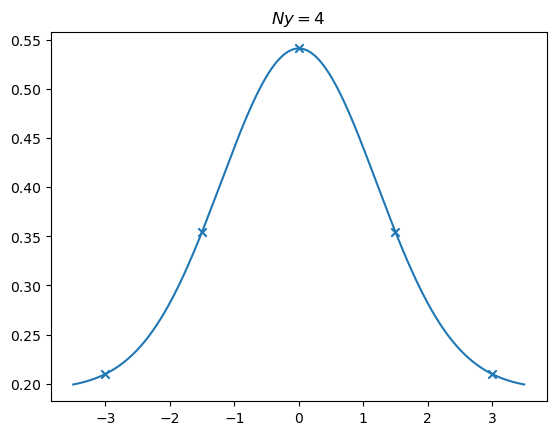

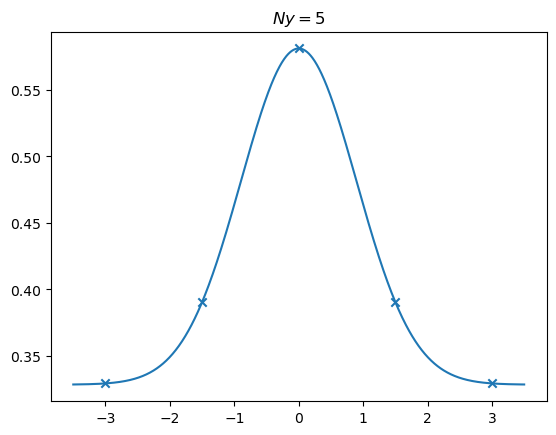

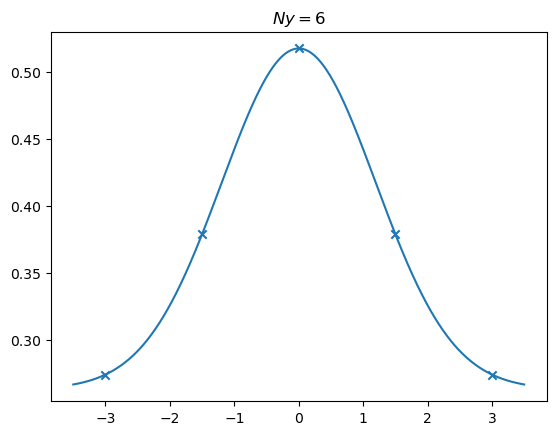

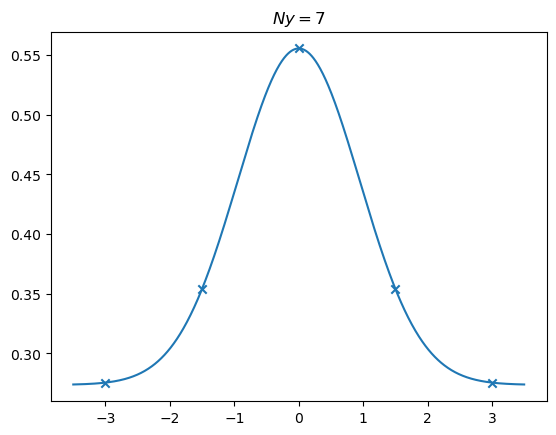

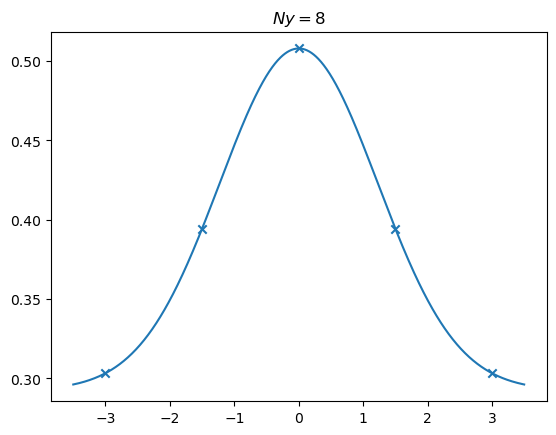

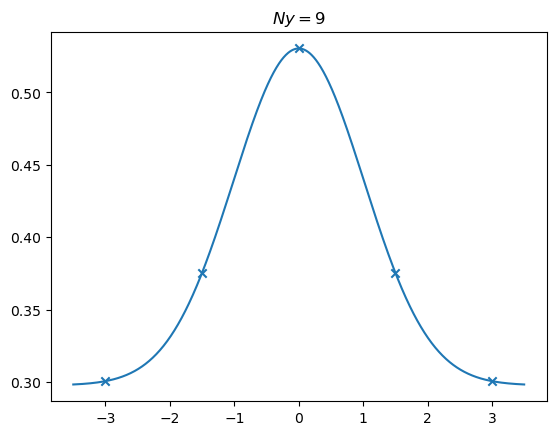

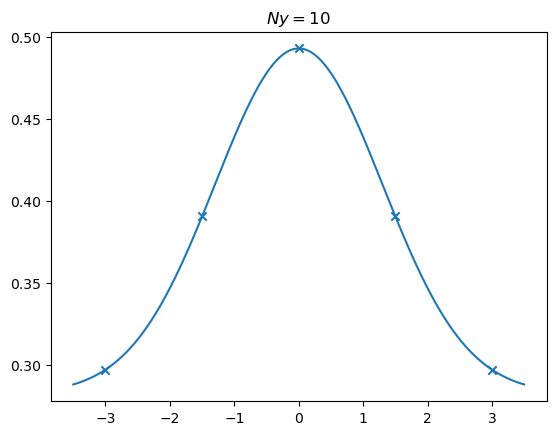

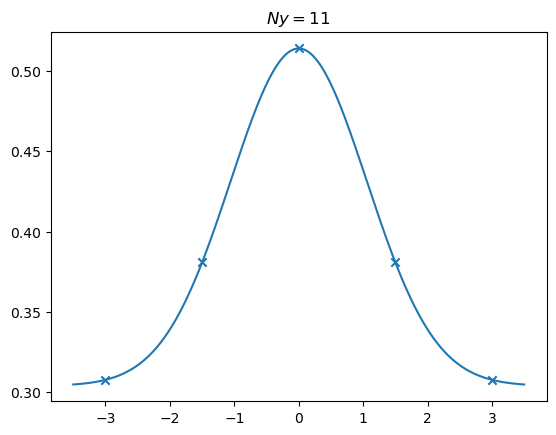

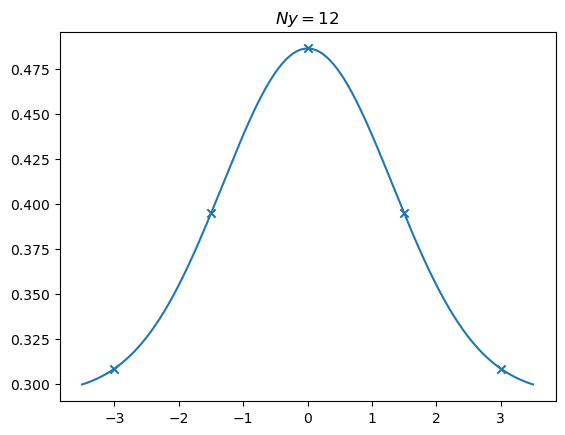

In [8]:

g2 = np.loadtxt(f"Nx4/string/AAA_g2_4x12.txt")
w = np.zeros((len(g2), len(Ny), Nx+1))

#g2_index = np.where(np.abs(g2 - g2_target) < 1e-5)[0]

#assert(len(g2_index) == 1)
#g2_index = g2_index[0]
for i, _Ny in enumerate(Ny):
    
    Ex = []
    for j in range(4):
        Ex_g2 = np.loadtxt(f"Nx4/string/AAA_ex{j}_{Nx}x{_Ny}.txt").reshape((-1,_Ny,Nx))
        Ex.append(Ex_g2)

    for j in range(len(g2)):
        if _Ny % 2 == 0:
            w[j,i,0] = Ex[1][j,_Ny//2  ,0] + Ex[2][j,_Ny//2  ,0]
            w[j,i,1] = Ex[1][j,_Ny//2-1,1] + Ex[3][j,_Ny//2-1,1]
            w[j,i,2] = Ex[1][j,_Ny//2  ,2] + Ex[2][j,_Ny//2  ,2]
            w[j,i,3] = Ex[1][j,_Ny//2-1,3] + Ex[3][j,_Ny//2-1,3]
            w[j,i,4] = Ex[1][j,_Ny//2  ,0] + Ex[2][j,_Ny//2  ,0]
        else:
            w[j,i,0] = Ex[1][j,_Ny//2,0] + Ex[3][j,_Ny//2,0]
            w[j,i,1] = Ex[1][j,_Ny//2,1] + Ex[2][j,_Ny//2,1]
            w[j,i,2] = Ex[1][j,_Ny//2,2] + Ex[3][j,_Ny//2,2]
            w[j,i,3] = Ex[1][j,_Ny//2,3] + Ex[2][j,_Ny//2,3]
            w[j,i,4] = Ex[1][j,_Ny//2,0] + Ex[3][j,_Ny//2,0]

x = (np.arange(0, Nx+1, 1) - 2) * 3/2
def gauss(x, A, omega, c):
    return A * np.exp(-x**2/(2*omega**2)) + c

A = np.zeros((len(g2), len(Ny)), dtype=object)
omega = np.zeros((len(g2), len(Ny)), dtype=object)
c = np.zeros((len(g2), len(Ny)), dtype=object)

for i, _w_g2 in enumerate(w):

    for j, _w in enumerate(_w_g2):
        opt, cov = sp.optimize.curve_fit(gauss, x, _w, bounds=[(0, 0, -np.inf), (np.inf, np.inf, np.inf)])
        A[i,j], omega[i,j], c[i,j] = correlated_values(opt, cov)

    #plt.figure()
    #plt.title(rf"$Ny={Ny[i]}$")
    #plt.scatter(x, _w, marker='x')
    #chi2 = np.sum((_w - gauss(x, *opt))**2) / (len(x) - len(opt))
    #x_fit = np.linspace(-3.5, 3.5, 1000)
    #plt.plot(x_fit, gauss(x_fit, *opt))

g2_filter = np.where(np.abs(g2 - 0.5) < 1e-5)[0][0]
for i, _w in enumerate(w[g2_filter]):
    plt.figure()
    plt.title(rf"$Ny={Ny[i]}$")
    plt.scatter(x, _w, marker='x')
    opt = [A[g2_filter,i].nominal_value, omega[g2_filter,i].nominal_value, c[g2_filter,i].nominal_value]
    chi2 = np.sum((_w - gauss(x, *opt))**2) / (len(x) - 3)
    x_fit = np.linspace(-3.5, 3.5, 1000)
    plt.plot(x_fit, gauss(x_fit, *opt))

A=0.0119+/-0.0012, b=-47+/-23, chi2=inf
A=0.080+/-0.006, b=1.4+/-1.0, chi2=inf
A=0.25+/-0.04, b=4.3+/-0.6, chi2=inf
A=0.163+/-0.009, b=-16+/-5, chi2=1013374845.35
A=0.230+/-0.007, b=-10.7+/-1.6, chi2=26536013658103.7
A=0.381+/-0.006, b=-7.2+/-0.7, chi2=216486704199.72


C:\Users\jleng\AppData\Local\Temp\ipykernel_14944\3110145644.py:18: RuntimeWarning: divide by zero encountered in divide
  chi2 = np.sum((unp.nominal_values(omega[i][Ny_filter]) - string_width(Ny[Ny_filter], *opt))**2 / unp.std_devs(omega[i][Ny_filter])**2) / (len(Ny[Ny_filter]) - len(opt))


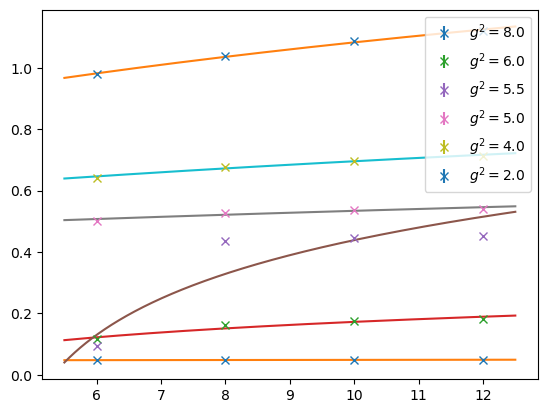

In [100]:
Ny_even = Ny % 2 == 0
Ny_filter = np.logical_and(Ny_even, Ny >= 6)

g2_filter = (np.abs(g2 - 2.0) < 1e-5) | (np.abs(g2 - 4.0) < 1e-5) | (np.abs(g2 - 5.0) < 1e-5) | (np.abs(g2 - 5.5) < 1e-5) | (np.abs(g2 - 6.0) < 1e-5) | (np.abs(g2 - 8.0) < 1e-5)

plt.figure()

def string_width(x, A, b):
    return A * np.log(x - b)

for i, _g2 in enumerate(g2):
    if not g2_filter[i]:
        continue

    plt.errorbar(Ny[Ny_filter], unp.nominal_values(omega[i][Ny_filter]), unp.std_devs(omega[i][Ny_filter]), fmt='x', label=fr"$g^2={round(_g2, 2)}$")

    opt, cov = sp.optimize.curve_fit(string_width, Ny[Ny_filter], unp.nominal_values(omega[i][Ny_filter]))
    chi2 = np.sum((unp.nominal_values(omega[i][Ny_filter]) - string_width(Ny[Ny_filter], *opt))**2 / unp.std_devs(omega[i][Ny_filter])**2) / (len(Ny[Ny_filter]) - len(opt))
    uopt = correlated_values(opt, cov)
    print(f"A={uopt[0]}, b={uopt[1]}, chi2={round(chi2, 2)}")

    omega_theo = np.linspace(5.5, 12.5, 1000)
    plt.plot(omega_theo, string_width(omega_theo, *opt))

plt.legend()